In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('accepted.csv', low_memory=False)

TARGET = "int_rate"

In [3]:
keep_cols = [
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "purpose",
    "initial_list_status",
    "application_type",  

    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "addr_state",
    "dti",
    "dti_joint", 

    "earliest_cr_line",  
    "issue_d",
    "fico_range_low",
    "inq_last_6mths",
    "inq_last_12m",
    "mths_since_last_delinq",
    "mths_since_last_record",
    "mths_since_recent_inq",
    "delinq_2yrs",
    "open_acc",
    "pub_rec",
    "pub_rec_bankruptcies",
    "tax_liens",
    "total_acc",
    "mort_acc",

    "revol_bal",
    "revol_util",
    "bc_util",
    "total_rev_hi_lim",
    "tot_cur_bal",
    "tot_coll_amt",
    "avg_cur_bal",
    "acc_now_delinq",

    "num_accts_ever_120_pd",
    "num_tl_90g_dpd_24m",
    "pct_tl_nvr_dlq",
    "chargeoff_within_12_mths",
]

In [4]:
keep_cols = [c for c in keep_cols if c in df.columns and c != TARGET]
df = df[keep_cols + [TARGET]].copy()
print(f"After column selection: {df.shape[1] - 1} features + target")

After column selection: 42 features + target


In [5]:
def parse_lc_date(series):
    return pd.to_datetime(series, format="%b-%Y", errors="coerce")
 
if "issue_d" in df.columns:
    df["loan_vintage_yr"] = parse_lc_date(df["issue_d"]).dt.year
    df.drop(columns=["issue_d"], inplace=True)
 
if "earliest_cr_line" in df.columns:
    reference_date = pd.Timestamp("2018-01-01")
    df["credit_history_yrs"] = (
        (reference_date - parse_lc_date(df["earliest_cr_line"])).dt.days / 365.25
    ).round(1)
    df.drop(columns=["earliest_cr_line"], inplace=True)

if "term" in df.columns:
    df["term"] = df["term"].str.extract(r"(\d+)").astype(float)

for col in ["revol_util"]:
    if col in df.columns and df[col].dtype == object:
        df[col] = df[col].str.replace("%", "").astype(float)

if "emp_length" in df.columns:
    emp_map = {
        "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3,
        "4 years": 4, "5 years": 5, "6 years": 6, "7 years": 7,
        "8 years": 8, "9 years": 9, "10+ years": 10
    }
    df["emp_length"] = df["emp_length"].map(emp_map)
 

In [6]:
null_pct = df.isnull().mean().sort_values(ascending=False)
print("\n── Null % per column (top 20) ──")
print(null_pct[null_pct > 0].head(20).map("{:.1%}".format))


── Null % per column (top 20) ──
dti_joint                   94.7%
mths_since_last_record      84.1%
mths_since_last_delinq      51.2%
inq_last_12m                38.3%
mths_since_recent_inq       13.1%
emp_length                   6.5%
bc_util                      3.4%
pct_tl_nvr_dlq               3.1%
avg_cur_bal                  3.1%
num_accts_ever_120_pd        3.1%
tot_cur_bal                  3.1%
total_rev_hi_lim             3.1%
tot_coll_amt                 3.1%
num_tl_90g_dpd_24m           3.1%
mort_acc                     2.2%
revol_util                   0.1%
dti                          0.1%
pub_rec_bankruptcies         0.1%
chargeoff_within_12_mths     0.0%
tax_liens                    0.0%
dtype: str


In [7]:
df["mths_since_last_delinq"] = df["mths_since_last_delinq"].fillna(999)

null_thresh = 0.50
null_pct = df.isnull().mean()
drop_cols = null_pct[null_pct > null_thresh].index.tolist()
df.drop(columns=drop_cols, inplace=True)

num_cols = df.select_dtypes(include="number").columns.drop(TARGET, errors="ignore").tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

/var/folders/k9/kvdd3gxn5xqfz8jv5jy4j7jc0000gn/T/ipykernel_39000/1672687768.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


In [8]:
# splits between data type
num_cols = df.select_dtypes(include="number").columns.drop(TARGET, errors="ignore").tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"\nFinal shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


Final shape: 2,260,701 rows × 41 columns


/var/folders/k9/kvdd3gxn5xqfz8jv5jy4j7jc0000gn/T/ipykernel_39000/3647101952.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


In [9]:
corr_rows = []
for col in num_cols:
    valid = df[[col, TARGET]].dropna()
    r, p = stats.pearsonr(valid[col], valid[TARGET])
    corr_rows.append({"variable": col, "correlation": round(r, 4), "p_value": round(p, 5)})

corr_df = pd.DataFrame(corr_rows).sort_values("correlation", key=abs, ascending=False)
print(corr_df.to_string(index=False))

                variable  correlation  p_value
          fico_range_low      -0.4160      0.0
                    term       0.3726      0.0
                 bc_util       0.2731      0.0
              revol_util       0.2625      0.0
          inq_last_6mths       0.1884      0.0
        total_rev_hi_lim      -0.1787      0.0
            inq_last_12m       0.1251      0.0
                     dti       0.1244      0.0
             installment       0.1239      0.0
   mths_since_recent_inq      -0.1232      0.0
      credit_history_yrs      -0.1033      0.0
               loan_amnt       0.0981      0.0
                mort_acc      -0.0882      0.0
             tot_cur_bal      -0.0831      0.0
  mths_since_last_delinq      -0.0816      0.0
             avg_cur_bal      -0.0804      0.0
          pct_tl_nvr_dlq      -0.0802      0.0
             delinq_2yrs       0.0589      0.0
    pub_rec_bankruptcies       0.0567      0.0
                 pub_rec       0.0534      0.0
   num_accts_

In [10]:
from scipy.stats import f_oneway

cat_assoc_rows = []
for col in cat_cols:
    groups = [df[df[col] == val][TARGET].dropna() for val in df[col].unique()]
    f, p = f_oneway(*groups)
    cat_assoc_rows.append({"variable": col, "f_statistic": round(f, 2), "p_value": round(p, 5)})

cat_assoc = pd.DataFrame(cat_assoc_rows).sort_values("f_statistic", ascending=False)
print(cat_assoc.to_string(index=False))

           variable  f_statistic  p_value
              grade   3755384.11      0.0
          sub_grade   1425929.99      0.0
verification_status     73644.05      0.0
initial_list_status     32951.39      0.0
            purpose      5732.29      0.0
     home_ownership      2512.05      0.0
   application_type      1917.48      0.0
         addr_state        47.86      0.0


In [11]:
summary = df[num_cols + [TARGET]].describe().T
print(summary)

                              count           mean            std      min  \
loan_amnt                 2260701.0   15046.899889    9190.182072   500.00   
term                      2260701.0      42.910218      10.867114    36.00   
installment               2260701.0     445.805833     267.171710     4.93   
emp_length                2260701.0       5.935821       3.597319     0.00   
annual_inc                2260701.0   77992.216045  112695.289600     0.00   
dti                       2260701.0      18.823437      14.177883    -1.00   
fico_range_low            2260701.0     698.588080      33.010152   610.00   
inq_last_6mths            2260701.0       0.576819       0.885956     0.00   
inq_last_12m              2260701.0       1.639480       1.938375     0.00   
mths_since_last_delinq    2260701.0     528.794515     482.322187     0.00   
mths_since_recent_inq     2260701.0       6.759637       5.603627     0.00   
delinq_2yrs               2260701.0       0.306871       0.86722

In [12]:
print(df.shape[0])

2260701


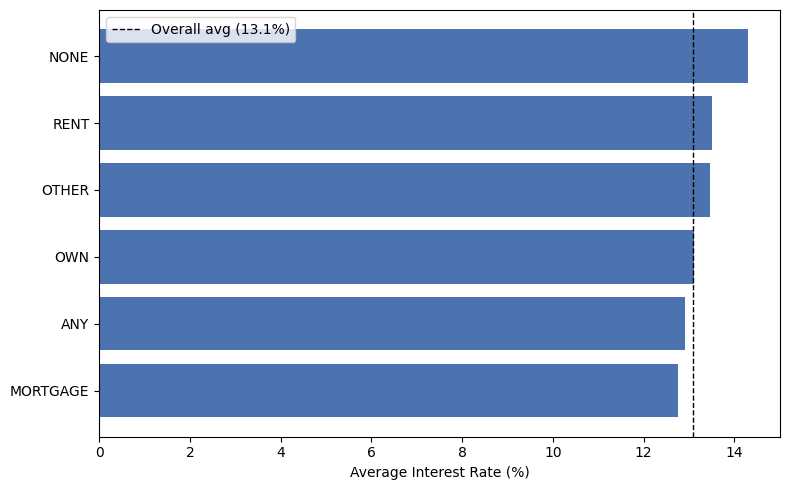

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
rate = df.groupby("home_ownership")[TARGET].mean().sort_values()
ax.barh(rate.index, rate.values, color="#4C72B0")
ax.axvline(df[TARGET].mean(), color="black", linestyle="--", linewidth=1,
           label=f"Overall avg ({df[TARGET].mean():.1f}%)")
ax.set_xlabel("Average Interest Rate (%)")
ax.legend()
plt.tight_layout()
plt.show()
plt.close()

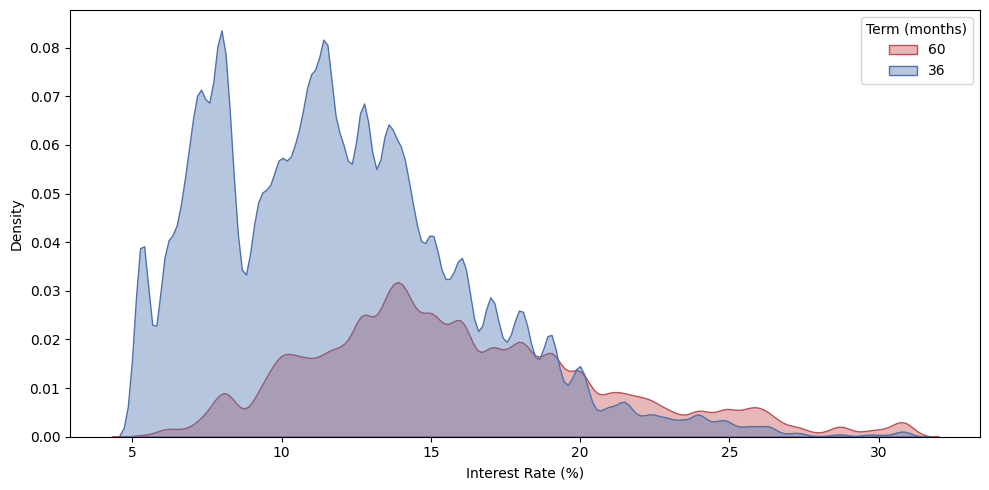

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(data=df, x=TARGET, hue="term",
            palette={36.0: "#4C72B0", 60.0: "#C44E52"}, fill=True, alpha=0.4, ax=ax)
ax.set_xlabel("Interest Rate (%)")
ax.legend(title="Term (months)", labels=["60", "36"])
plt.tight_layout()
plt.show()
plt.close()

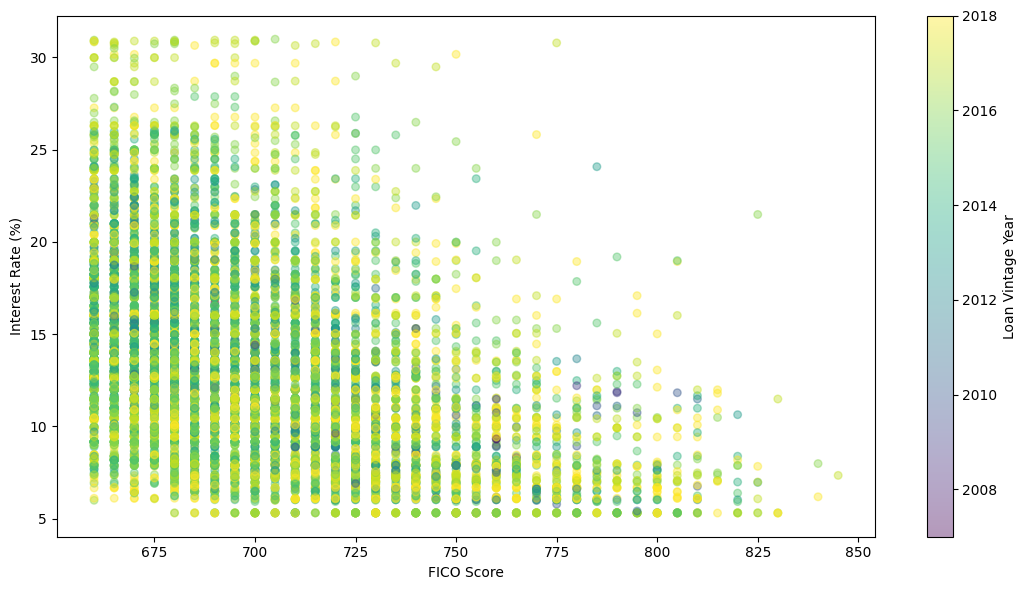

In [21]:
fig, ax = plt.subplots(figsize=(11, 6))
sample = df.sample(n=10000, random_state=42)
scatter = ax.scatter(sample["fico_range_low"], sample[TARGET],
                     c=sample["loan_vintage_yr"], cmap="viridis", alpha=0.4, s=30)
plt.colorbar(scatter, ax=ax, label="Loan Vintage Year")
ax.set_xlabel("FICO Score")
ax.set_ylabel("Interest Rate (%)")
plt.tight_layout()
plt.show()
plt.close()

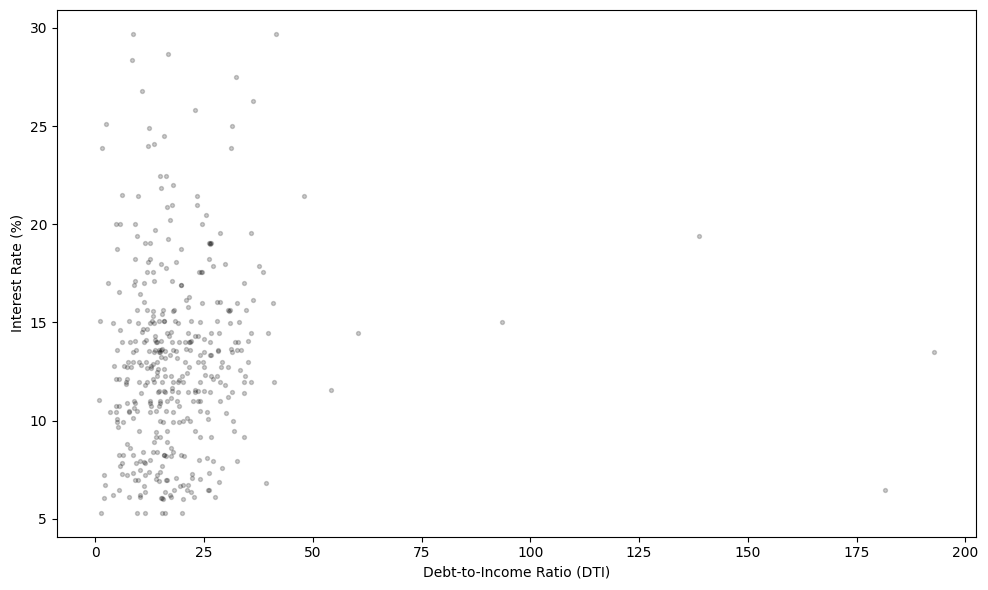

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
sample = df.sample(n=400, random_state=42)
ax.scatter(sample["dti"], sample[TARGET], alpha=0.2, s=8, color="black")
ax.set_xlabel("Debt-to-Income Ratio (DTI)")
ax.set_ylabel("Interest Rate (%)")
plt.tight_layout()
plt.show()
plt.close()

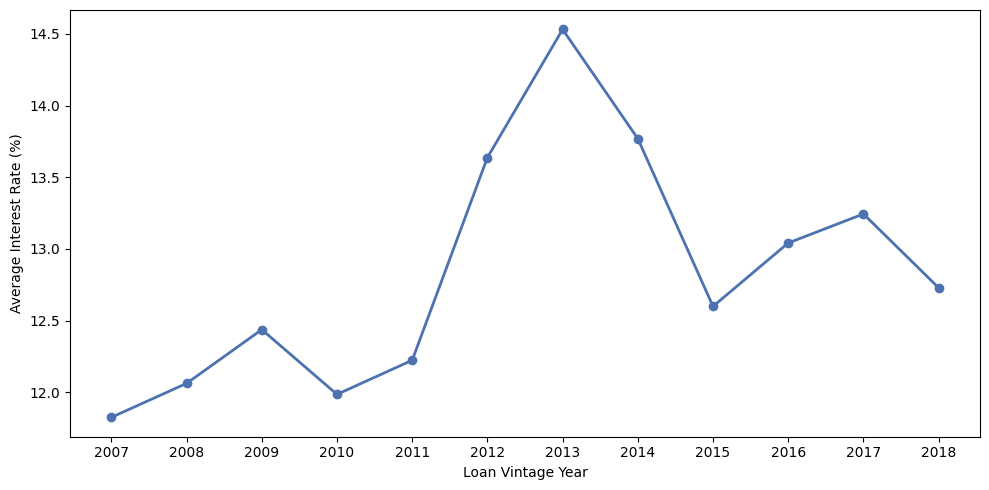

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
trend = df.groupby("loan_vintage_yr")[TARGET].mean()
ax.plot(trend.index, trend.values, marker="o", color="#4C72B0", linewidth=2)
ax.set_xlabel("Loan Vintage Year")
ax.set_ylabel("Average Interest Rate (%)")
ax.set_xticks(trend.index)
plt.tight_layout()

plt.show()
plt.close()

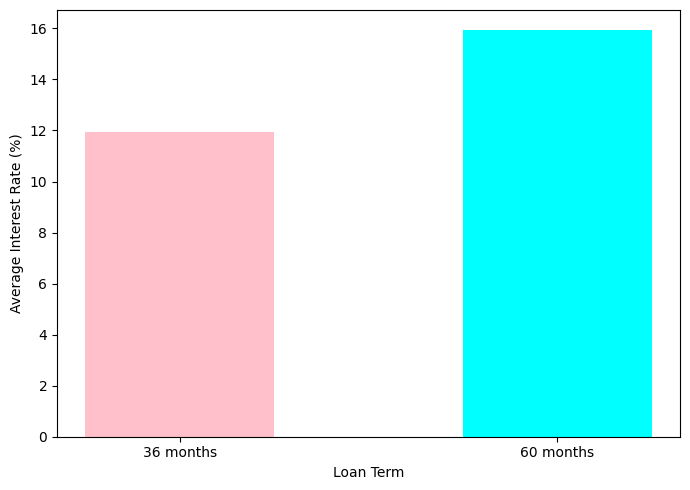

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
rate = df.groupby("term")[TARGET].mean()
ax.bar(["36 months", "60 months"], rate.values, color=["pink", "cyan"], width=0.5)
ax.set_ylabel("Average Interest Rate (%)")
ax.set_xlabel("Loan Term")
plt.tight_layout()
plt.show()
plt.close()

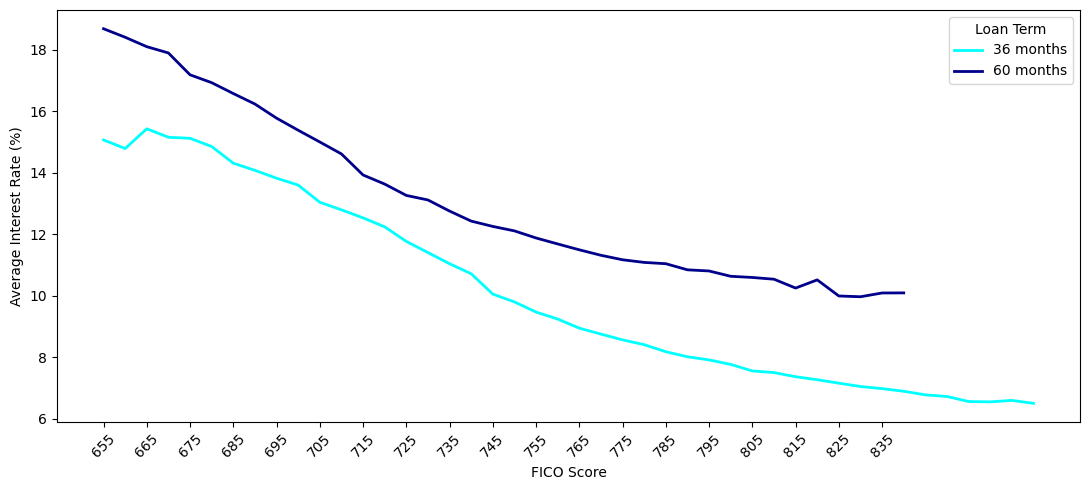

In [28]:
fig, ax = plt.subplots(figsize=(11, 5))
df["fico_bin"] = pd.cut(df["fico_range_low"], bins=range(625, 855, 5))
for term, color, label in [(36.0, "cyan", "36 months"), (60.0, "darkblue", "60 months")]:
    fico_rate = df[df["term"] == term].groupby("fico_bin")[TARGET].mean()
    ax.plot(range(len(fico_rate)), fico_rate.values, color=color, linewidth=2, label=label)
ax.set_xticks(range(0, len(fico_rate), 2))
ax.set_xticklabels([str(b.left) for b in fico_rate.index[::2]], rotation=45)
ax.set_xlabel("FICO Score")
ax.set_ylabel("Average Interest Rate (%)")
ax.legend(title="Loan Term")
plt.tight_layout()

plt.show()
plt.close()

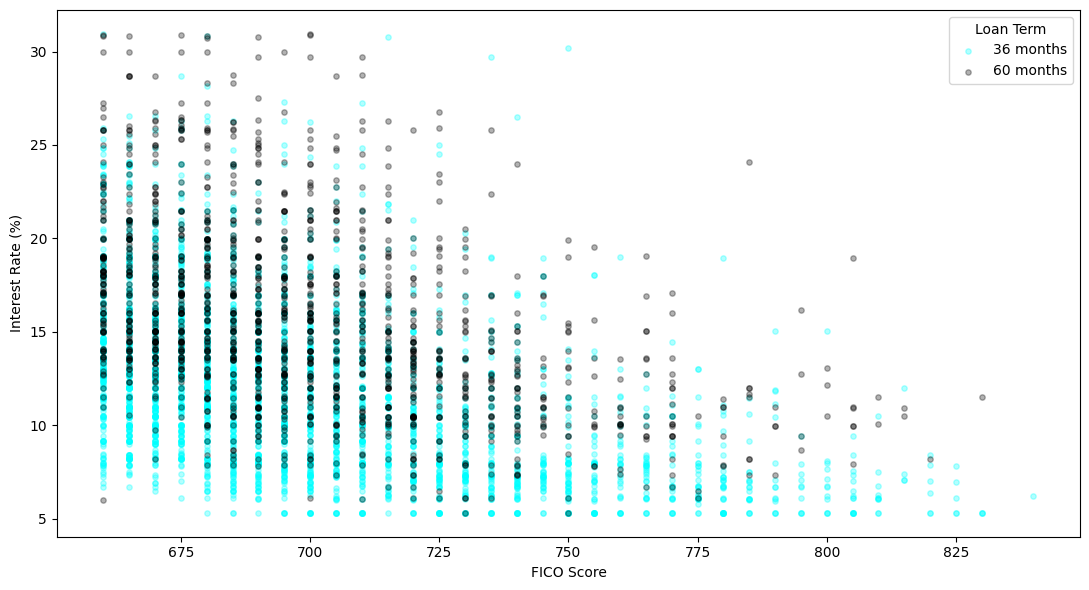

In [30]:
fig, ax = plt.subplots(figsize=(11, 6))
sample = df.sample(n=5000, random_state=42)
for term, color, label in [(36.0, "cyan", "36 months"), (60.0, "black", "60 months")]:
    sub = sample[sample["term"] == term]
    ax.scatter(sub["fico_range_low"], sub[TARGET], color=color, alpha=0.3, s=15, label=label)
ax.set_xlabel("FICO Score")
ax.set_ylabel("Interest Rate (%)")
ax.legend(title="Loan Term")
plt.tight_layout()
plt.show()
plt.close()